# GNP Production Data - Initial Exploration
## Phase 1: Database Connection & Phase 2: Initial Data Exploration

In [5]:
import os
import sys
import django
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Configure Django settings
project_path = r'C:\Users\sarath.pr\Documents\DEV\Production_KPI'
if project_path not in sys.path:
    sys.path.append(project_path)

os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'production_kpi.settings')
django.setup()

# Import models
from upload_from_pi.models import ProductionReport, BookWiseDetails, Innovation, Downtime, WebBreak, ReelConsumption

print("✓ Django configured successfully")
print("✓ Models imported successfully")

✓ Django configured successfully
✓ Models imported successfully


### Phase 1: Database Connection Test

In [7]:
# Test database connection
from django.db import connection
from asgiref.sync import sync_to_async

async def test_db_connection():
    try:
        def get_db_version():
            with connection.cursor() as cursor:
                cursor.execute("SELECT version();")
                return cursor.fetchone()
        
        db_version = await sync_to_async(get_db_version)()
        print("✓ Database connection successful")
        print(f"PostgreSQL version: {db_version[0]}")
    except Exception as e:
        print(f"✗ Database connection failed: {e}")

await test_db_connection()

✓ Database connection successful
PostgreSQL version: PostgreSQL 16.4, compiled by Visual C++ build 1940, 64-bit


### Phase 2: Initial Data Exploration
#### 2.1 Basic Statistics - Row Counts

TABLE ROW COUNTS
ProductionReport..............     20,163
BookWiseDetails...............     32,509
Innovation....................     22,626
Downtime......................      4,317
WebBreak......................      1,084
ReelConsumption...............    130,685


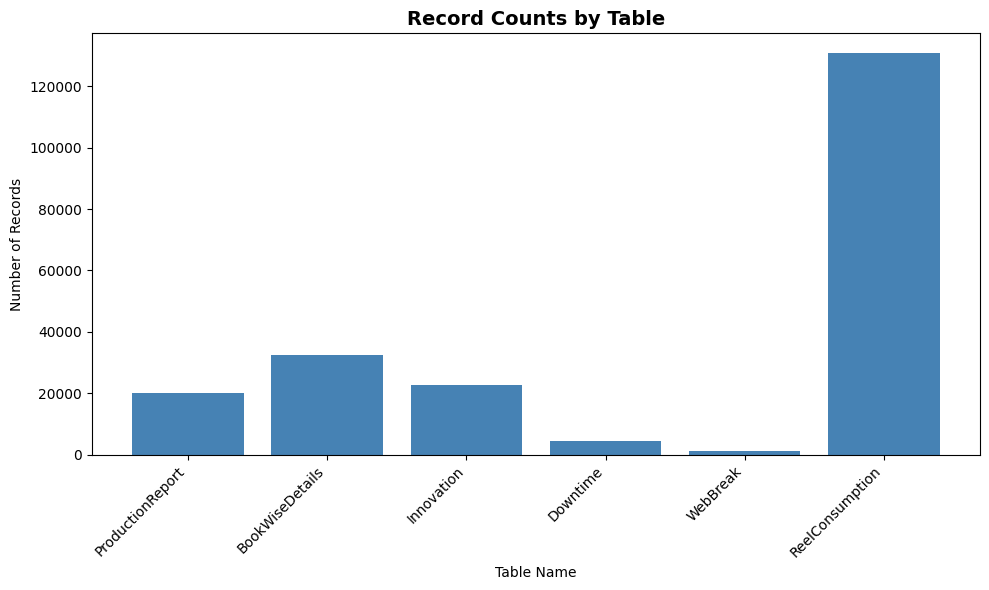

In [9]:
# Get row counts for all tables
from asgiref.sync import sync_to_async

async def get_table_stats():
    table_stats = {
        'ProductionReport': await sync_to_async(ProductionReport.objects.count)(),
        'BookWiseDetails': await sync_to_async(BookWiseDetails.objects.count)(),
        'Innovation': await sync_to_async(Innovation.objects.count)(),
        'Downtime': await sync_to_async(Downtime.objects.count)(),
        'WebBreak': await sync_to_async(WebBreak.objects.count)(),
        'ReelConsumption': await sync_to_async(ReelConsumption.objects.count)()
    }
    return table_stats

table_stats = await get_table_stats()

print("=" * 50)
print("TABLE ROW COUNTS")
print("=" * 50)
for table, count in table_stats.items():
    print(f"{table:.<30} {count:>10,}")
print("=" * 50)

# Visualize
plt.figure(figsize=(10, 6))
plt.bar(table_stats.keys(), table_stats.values(), color='steelblue')
plt.title('Record Counts by Table', fontsize=14, fontweight='bold')
plt.ylabel('Number of Records')
plt.xlabel('Table Name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 2.2 Date Range Coverage

In [11]:
#  Date range analysis
from django.db.models import Min, Max
from asgiref.sync import sync_to_async

async def get_date_ranges():
    # ProductionReport
    pr_dates = await sync_to_async(ProductionReport.objects.aggregate)(min_date=Min('issue_date'), max_date=Max('issue_date'))
    
    # BookWiseDetails
    bwd_dates = await sync_to_async(BookWiseDetails.objects.aggregate)(min_date=Min('issue_date'), max_date=Max('issue_date'))
    
    # Innovation
    inn_dates = await sync_to_async(Innovation.objects.aggregate)(min_date=Min('issue_date'), max_date=Max('issue_date'))
    
    return pr_dates, bwd_dates, inn_dates

pr_dates, bwd_dates, inn_dates = await get_date_ranges()

print("=" * 70)
print("DATE RANGE COVERAGE")
print("=" * 70)

# ProductionReport
if pr_dates['min_date'] and pr_dates['max_date']:
    days_span = (pr_dates['max_date'] - pr_dates['min_date']).days
    print(f"ProductionReport:")
    print(f"  From: {pr_dates['min_date']} | To: {pr_dates['max_date']} | Span: {days_span} days")

# BookWiseDetails
if bwd_dates['min_date'] and bwd_dates['max_date']:
    days_span = (bwd_dates['max_date'] - bwd_dates['min_date']).days
    print(f"\nBookWiseDetails:")
    print(f"  From: {bwd_dates['min_date']} | To: {bwd_dates['max_date']} | Span: {days_span} days")

# Innovation
if inn_dates['min_date'] and inn_dates['max_date']:
    days_span = (inn_dates['max_date'] - inn_dates['min_date']).days
    print(f"\nInnovation:")
    print(f"  From: {inn_dates['min_date']} | To: {inn_dates['max_date']} | Span: {days_span} days")

print("=" * 70)

DATE RANGE COVERAGE
ProductionReport:
  From: 2024-08-01 | To: 2025-10-02 | Span: 427 days

BookWiseDetails:
  From: 2024-08-01 | To: 2025-10-02 | Span: 427 days

Innovation:
  From: 2024-08-01 | To: 2025-10-02 | Span: 427 days


#### 2.3 Plant, Machine, and Folder Distribution

In [14]:
# Plant, Machine and Folder distribution
from django.db.models import Count
from asgiref.sync import sync_to_async

async def get_distributions():
    # Plant distribution
    def get_plant_dist():
        return list(ProductionReport.objects.values('plant_name').annotate(count=Count('issueid')).order_by('-count'))
    
    # Machine distribution (top 10)
    def get_machine_dist():
        return list(ProductionReport.objects.values('machine').annotate(count=Count('issueid')).order_by('-count')[:10])
    
    # Folder distribution (top 10)
    def get_folder_dist():
        return list(ProductionReport.objects.values('folder').annotate(count=Count('issueid')).order_by('-count')[:10])
    
    plant_dist = await sync_to_async(get_plant_dist)()
    machine_dist = await sync_to_async(get_machine_dist)()
    folder_dist = await sync_to_async(get_folder_dist)()
    
    return plant_dist, machine_dist, folder_dist

plant_dist, machine_dist, folder_dist = await get_distributions()

# Plant distribution
print("=" * 50)
print("PLANT DISTRIBUTION")
print("=" * 50)
for item in plant_dist:
    print(f"{item['plant_name']:.<30} {item['count']:>10,}")
print("=" * 50)

# Machine distribution (top 10)
print("\n" + "=" * 50)
print("TOP 10 MACHINES")
print("=" * 50)
for item in machine_dist:
    print(f"{item['machine']:.<30} {item['count']:>10,}")
print("=" * 50)

# Folder distribution (top 10)
print("\n" + "=" * 50)
print("TOP 10 FOLDERS")
print("=" * 50)
for item in folder_dist:
    print(f"{item['folder']:.<30} {item['count']:>10,}")
print("=" * 50)

PLANT DISTRIBUTION
Airoli........................      4,987
Bhosari.......................      2,438
Baroda........................      2,437
Sahibabad.....................      1,936
Bommasandra...................      1,624
Kandivali.....................      1,308
Saltlake......................      1,286
Vejalpur......................      1,078
Chinhat.......................        834
Nacharam......................        612
Chemmencherry.................        605
Manesar.......................        580
Butibori......................        304
Trivandrum....................        134

TOP 10 MACHINES
Regioman......................      3,430
Hiline........................      2,741
Colorman-B....................      2,368
Colorman-A....................      1,701
Cromoman-C....................      1,500
Regioman B....................      1,111
Cromoman......................        899
Hiline 2......................        778
Cityline -1...................        76

#### 2.4 Convert to DataFrames for Detailed Analysis

In [16]:
# Convert to DataFrames
from asgiref.sync import sync_to_async

async def get_dataframes():
    pr_fields = [f.name for f in ProductionReport._meta.get_fields() if not f.many_to_many and not f.one_to_many]
    def get_pr_data():
        return list(ProductionReport.objects.all().values(*pr_fields))
    df_pr = pd.DataFrame(await sync_to_async(get_pr_data)())
    
    bwd_fields = [f.name for f in BookWiseDetails._meta.get_fields() if not f.many_to_many and not f.one_to_many]
    def get_bwd_data():
        return list(BookWiseDetails.objects.all().values(*bwd_fields))
    df_bwd = pd.DataFrame(await sync_to_async(get_bwd_data)())
    
    inn_fields = [f.name for f in Innovation._meta.get_fields() if not f.many_to_many and not f.one_to_many]
    def get_inn_data():
        return list(Innovation.objects.all().values(*inn_fields))
    df_inn = pd.DataFrame(await sync_to_async(get_inn_data)())
    
    return df_pr, df_bwd, df_inn

df_pr, df_bwd, df_inn = await get_dataframes()

print(f"ProductionReport: {df_pr.shape}")
print(f"BookWiseDetails: {df_bwd.shape}")
print(f"Innovation: {df_inn.shape}")

ProductionReport: (20163, 58)
BookWiseDetails: (32509, 53)
Innovation: (22626, 18)


#### 2.5 Data Quality - Missing Values Analysis

In [17]:
# Missing values for ProductionReport
print("=" * 80)
print("PRODUCTION REPORT - MISSING VALUES")
print("=" * 80)
if len(df_pr) > 0:
    missing = pd.DataFrame({
        'Column': df_pr.columns,
        'Missing': df_pr.isnull().sum().values,
        'Pct': (df_pr.isnull().sum().values / len(df_pr) * 100).round(2)
    }).sort_values('Pct', ascending=False)
    print(missing[missing['Missing'] > 0].to_string(index=False) if len(missing[missing['Missing'] > 0]) > 0 else "✓ No missing values")
print("=" * 80)

PRODUCTION REPORT - MISSING VALUES
                      Column  Missing   Pct
                     tabloid    19432 96.37
reason_for_additional_folder    18103 89.78
                 last_bundle    15629 77.51
             innovation_rank     8276 41.05
                broad_sheets      759  3.76
                 color_pages      167  0.83


In [18]:
# Missing values for BookWiseDetails
print("=" * 80)
print("BOOK WISE DETAILS - MISSING VALUES")
print("=" * 80)
if len(df_bwd) > 0:
    missing_bwd = pd.DataFrame({
        'Column': df_bwd.columns,
        'Missing': df_bwd.isnull().sum().values,
        'Pct': (df_bwd.isnull().sum().values / len(df_bwd) * 100).round(2)
    }).sort_values('Pct', ascending=False)
    print(missing_bwd[missing_bwd['Missing'] > 0].to_string(index=False) if len(missing_bwd[missing_bwd['Missing'] > 0]) > 0 else "✓ No missing values")
print("=" * 80)

BOOK WISE DETAILS - MISSING VALUES
       Column  Missing   Pct
     replates    27419 84.34
  last_bundle    25342 77.95
startup_waste      548  1.69
   last_plate        1  0.00


In [19]:
# Missing values for Innovation
print("=" * 80)
print("INNOVATION - MISSING VALUES")
print("=" * 80)
if len(df_inn) > 0:
    missing_inn = pd.DataFrame({
        'Column': df_inn.columns,
        'Missing': df_inn.isnull().sum().values,
        'Pct': (df_inn.isnull().sum().values / len(df_inn) * 100).round(2)
    }).sort_values('Pct', ascending=False)
    print(missing_inn[missing_inn['Missing'] > 0].to_string(index=False) if len(missing_inn[missing_inn['Missing'] > 0]) > 0 else "✓ No missing values")
print("=" * 80)

INNOVATION - MISSING VALUES
Column  Missing   Pct
 runid     6445 28.48


#### 2.6 Duplicate Analysis

In [20]:
# Duplicate analysis
print("=" * 70)
print("DUPLICATE ANALYSIS")
print("=" * 70)
if len(df_pr) > 0:
    print(f"ProductionReport duplicates: {df_pr['issueid'].duplicated().sum()}")
if len(df_bwd) > 0:
    print(f"BookWiseDetails duplicates: {df_bwd['book_id'].duplicated().sum()}")
if len(df_inn) > 0:
    print(f"Innovation duplicates: {df_inn['innovation_id'].duplicated().sum()}")
print("=" * 70)

DUPLICATE ANALYSIS
ProductionReport duplicates: 0
BookWiseDetails duplicates: 0
Innovation duplicates: 0


#### 2.7 Numeric Statistics

In [21]:
# Numeric statistics
print("=" * 100)
print("PRODUCTION REPORT - KEY NUMERIC STATISTICS")
print("=" * 100)
if len(df_pr) > 0:
    cols = ['print_order', 'gross_counter', 'waste', 'waste_percentage', 'total_run_time_mnts', 
            'total_downtime', 'number_of_stoppages', 'avg_speed', 'final_score', 'waste_score']
    available = [c for c in cols if c in df_pr.columns]
    if available:
        print(df_pr[available].describe().round(2))
print("=" * 100)

PRODUCTION REPORT - KEY NUMERIC STATISTICS
       print_order  gross_counter      waste  total_run_time_mnts  \
count     20163.00       20163.00   20163.00             20163.00   
mean      47150.05       48304.72    1154.67                55.37   
std       51786.72       52416.88    1729.24                50.62   
min           0.00           0.00       0.00                 1.00   
25%       12256.00       12661.00     405.00                20.00   
50%       24850.00       25967.00     750.00                40.00   
75%       62819.50       63730.00    1403.50                77.00   
max      379925.00      385360.00  110000.00              1420.00   

       total_downtime  number_of_stoppages  
count        20163.00             20163.00  
mean             1.92                 0.20  
std              6.49                 0.55  
min              0.00                 0.00  
25%              0.00                 0.00  
50%              0.00                 0.00  
75%              0.0

In [27]:
df_inn.columns

Index(['innovation_id', 'issueid', 'bookid', 'issue_date', 'runid',
       'product_name', 'desk', 'edition', 'machine', 'folder', 'innovation',
       'impact', 'complexity', 'complexities', 'plant_name', 'production_type',
       'uv', 'reflong'],
      dtype='object')

In [36]:
# Identify unique innovations where uv = 'TRUE'
uv_innovations = df_inn[df_inn['uv'] == True]

print("=" * 80)
print("UNIQUE UV INNOVATIONS")
print("=" * 80)
print(f"Total UV innovations: {len(uv_innovations):,}")
print(f"Unique innovation types: {uv_innovations['innovation'].nunique() if 'innovation' in uv_innovations.columns else 'N/A'}")
print("\n")

# Display unique values
if len(uv_innovations) > 0:
    if 'innovation' in uv_innovations.columns:
        print("Innovation Types:")
        print(uv_innovations['innovation'].value_counts())
    
    print(f"\nUnique plants: {uv_innovations['plant_name'].nunique() if 'plant_name' in uv_innovations.columns else 'N/A'}")
    print(f"Unique issues: {uv_innovations['issueid'].nunique() if 'issueid' in uv_innovations.columns else 'N/A'}")
else:
    print("No UV innovations found")

print("=" * 80)

UNIQUE UV INNOVATIONS
Total UV innovations: 7,002
Unique innovation types: 25


Innovation Types:
innovation
GNP Jacket                           2578
Full Page Jacket                     2111
1/2 Flap with Glue                    545
1/2 Flap                              532
Bookmark                              312
Power Jacket (GNP)                    242
Center Spread Panorama                230
Full Page with gluing                 129
Front Vantage GNP                     100
Seamless Panorama                      67
GNP FRENCH WINDOW                      34
1-4 GNP Jacket                         30
Bookmark with glue                     23
LWC Jacket                             16
1-8 GNP Jacket                         13
Seamless Panorama With Bookmark        10
HD French Window (All 4 page GNP)       9
Center spread GNP                       7
French Window SNP                       3
Front Vantage SNP                       3
Super Panorama GNP (Magnifique)         2
Gate Seal

In [35]:
uv_innovations.columns

Index(['innovation_id', 'issueid', 'bookid', 'issue_date', 'runid',
       'product_name', 'desk', 'edition', 'machine', 'folder', 'innovation',
       'impact', 'complexity', 'complexities', 'plant_name', 'production_type',
       'uv', 'reflong'],
      dtype='object')

In [38]:
# Create nested dictionary: {plant_name: [(product_name, desk), ...]}
plant_product_desk_mapping = {}

if len(df_inn) > 0:
    # Get unique combinations of plant_name, product_name, and desk
    unique_combinations = df_inn[['plant_name', 'product_name', 'desk']].drop_duplicates()

    # Group by plant_name
    for plant in unique_combinations['plant_name'].unique():
        plant_data = unique_combinations[unique_combinations['plant_name'] == plant]
        # Store as list of tuples (product_name, desk)
        plant_product_desk_mapping[plant] = [
            (row['product_name'], row['desk'])
            for _, row in plant_data.iterrows()
        ]

    # Display the mapping
    print("=" * 80)
    print("PLANT-PRODUCT-DESK MAPPING")
    print("=" * 80)
    for plant, combinations in sorted(plant_product_desk_mapping.items()):
        print(f"\n{plant}:")
        print(f"  Total unique combinations: {len(combinations)}")
        print(f"  Combinations:")
        for product, desk in sorted(combinations):
            print(f"    • {product} | {desk}")
    print("\n" + "=" * 80)

    # Summary statistics
    print("\nSUMMARY STATISTICS:")
    print(f"Total plants: {len(plant_product_desk_mapping)}")
    print(f"Average combinations per plant: {np.mean([len(v) for v in plant_product_desk_mapping.values()]):.2f}")
    print(f"Max combinations in a plant: {max([len(v) for v in plant_product_desk_mapping.values()])}")
    print(f"Min combinations in a plant: {min([len(v) for v in plant_product_desk_mapping.values()])}")
    print("=" * 80)
else:
    print("No Innovation data available")


PLANT-PRODUCT-DESK MAPPING

Airoli:
  Total unique combinations: 31
  Combinations:
    • ASCENT - MUMBAI | Others-Asc
    • BOMBAY TIMES | TIMS
    • BOMBAY TIMES SECTION-2 | TIMS-Sec 2
    • CHEMBUR GHATKOPAR PLUS | TIMS
    • DOMBIVILI KALYAN PLUS | TIMS
    • EDUCATION TIMES - MUMBAI | Others-Edu
    • MAHARASHTRA TIMES - MUMBAI SECTION-2 | MT Sec 2
    • MAHARASHTRA TIMES-MUMBAI (CITY) | MT
    • MAHARASHTRA TIMES-MUMBAI (NASHIK) | MT
    • MT - NASIK PLUS | MT-Sup
    • MULUND PLUS | TIMS
    • MUMBAI MIRROR | Mirror
    • MUMBAI TIMES | MT-Sup
    • MUMBAI TIMES - NAVI MUMBAI PLUS | MT-Sup
    • MUMBAI TIMES - THANE PLUS | MT-Sup
    • Mumbai Mirror on Sunday (Tabloid) | Mirror
    • NASHIK TIMES | TIMS
    • NAVI MUMBAI PLUS | TIMS
    • SUNDAY TIMES OF INDIA-MUMBAI (CITY-2) | TOI-MAIN
    • THANE PLUS | TIMS
    • THE TIMES OF INDIA - MUMBAI SECTION-2 | TOI Sec-2
    • THE TIMES OF INDIA - NASHIK (MUMBAI) | TOI
    • THE TIMES OF INDIA - THANE CITY | TOI
    • THE TIMES OF IND